# LIME Image Template

**InceptionV3**

InceptionV3 is a deep convolutional neural network (CNN) architecture developed by Google and pre-trained on the ImageNet dataset for multi-class image classification. It requires specific input preprocessing, taking images resized to $299 \times 299$ pixels with pixel values normalized into the $[-1, 1]$ range.

In [ ]:
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


  0%|          | 0/1000 [00:00<?, ?it/s]

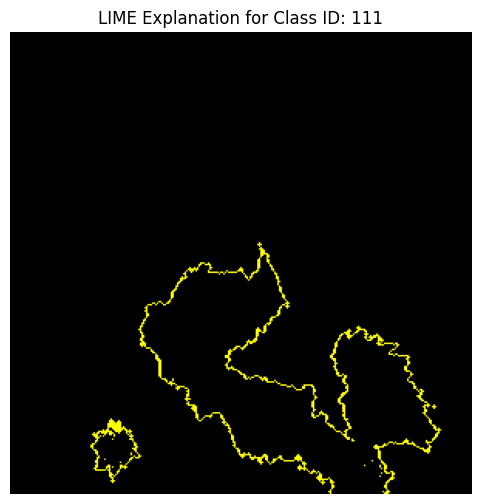

In [ ]:
from lime import lime_image

from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# 1. Load pre-trained model
model = InceptionV3(weights='imagenet')

# 2. Load and preprocess input image (299x299 for InceptionV3)
# Replace 'cat_mouse.jpg' with the target image path

import os
import urllib.request

# Λήψη δοκιμαστικής εικόνας (dog.jpg)
img_url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
img_path = "dog.jpg"
if not os.path.exists(img_path):
  urllib.request.urlretrieve(img_url, img_path)

# Φόρτωση
img = image.load_img(img_path, target_size=(299, 299))

img = image.load_img(img_path, target_size=(299, 299))
img_array = image.img_to_array(img)
img_tensor = np.expand_dims(img_array, axis=0)
img_tensor = preprocess_input(img_tensor)

# 3. Predict wrapper: Εφαρμόζει το preprocess_input σε κάθε batch διαταραχών της LIME
def predict_fn(images):
  # Οι διαταραγμένες εικόνες της LIME έρχονται σε [0, 255] -> γίνονται [-1, 1] για το InceptionV3
  preprocessed = preprocess_input(images.copy())
  return model.predict(preprocessed, verbose=0)

# 4. Initialize LIME Image Explainer
explainer = lime_image.LimeImageExplainer(random_state=42)

# classifier_fn: Function that receives an image batch and returns class probabilities
explanation = explainer.explain_instance(
    image=img_array.astype('double'),
    classifier_fn=predict_fn,
    top_labels=1,
    hide_color=0,  # Fill value for masked superpixels (0 = black/gray)
    num_samples=1000,  # Number of perturbed samples to evaluate
)

# 5. Extract superpixel mask and visualize saliency map overlay
top_pred_label = explanation.top_labels[0]
temp, mask = explanation.get_image_and_mask(
    label=top_pred_label,
    positive_only=True,    # Display only superpixels that increase class probability
    num_features=5,        # Top N most influential superpixels to show
    hide_rest=False        # Retain the remaining background image
)

# Plot the original image overlaid with highlighted superpixel boundaries
plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.axis('off')
plt.title(f'LIME Explanation for Class ID: {top_pred_label}')
plt.show()